### EDA 공유본

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
building_info = pd.read_csv('./building_info.csv')
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

In [68]:
train_df.head(3)

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh)
0,1_20220601 00,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28
1,1_20220601 01,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36
2,1_20220601 02,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88


In [69]:
train_df = train_df.rename(columns={
    '건물번호': 'building_number',
    '일시': 'date_time',
    '기온(C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'windspeed',
    '습도(%)': 'humidity',
    '일조(hr)': 'sunshine',
    '일사(MJ/m2)': 'solar_radiation',
    '전력소비량(kWh)': 'power_consumption'
})

In [70]:
train_df.drop('num_date_time', axis = 1, inplace=True)

In [71]:
train_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88


In [72]:
test_df.head(3)

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%)
0,1_20220825 00,1,20220825 00,23.5,0.0,2.2,72
1,1_20220825 01,1,20220825 01,23.0,0.0,0.9,72
2,1_20220825 02,1,20220825 02,22.7,0.0,1.5,75


In [73]:
test_df = test_df.rename(columns={
    '건물번호': 'building_number',
    '일시': 'date_time',
    '기온(C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'windspeed',
    '습도(%)': 'humidity',
    '일조(hr)': 'sunshine',
    '일사(MJ/m2)': 'solar_radiation',
    '전력소비량(kWh)': 'power_consumption'
})

In [74]:
test_df.drop('num_date_time', axis = 1, inplace=True)

In [75]:
test_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity
0,1,20220825 00,23.5,0.0,2.2,72
1,1,20220825 01,23.0,0.0,0.9,72
2,1,20220825 02,22.7,0.0,1.5,75


In [76]:
building_info.head(3)

,건물번호,건물유형,연면적(m2),냉방면적(m2),태양광용량(kW),ESS저장용량(kWh),PCS용량(kW)
0,1,건물기타,110634.00,39570.0,-,-,-
1,2,건물기타,122233.47,99000.0,-,-,-
2,3,건물기타,171243.00,113950.0,40,-,-


In [77]:
building_info = building_info.rename(columns={
    '건물번호': 'building_number',
    '건물유형': 'building_type',
    '연면적(m2)': 'total_area',
    '냉방면적(m2)': 'cooling_area',
    '태양광용량(kW)': 'solar_power_capacity',
    'ESS저장용량(kWh)': 'ess_capacity',
    'PCS용량(kW)': 'pcs_capacity'
})

In [78]:
translation_dict = {
    '건물기타': 'Other Buildings',
    '공공': 'Public',
    '대학교': 'University',
    '데이터센터': 'Data Center',
    '백화점및아울렛': 'Department Store and Outlet',
    '병원': 'Hospital',
    '상용': 'Commercial',
    '아파트': 'Apartment',
    '연구소': 'Research Institute',
    '지식산업센터': 'Knowledge Industry Center',
    '할인마트': 'Discount Mart',
    '호텔및리조트': 'Hotel and Resort'
}

In [79]:
building_info['building_type'] = building_info['building_type'].replace(translation_dict)

In [80]:
building_info.head(3)

,building_number,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity
0,1,Other Buildings,110634.00,39570.0,-,-,-
1,2,Other Buildings,122233.47,99000.0,-,-,-
2,3,Other Buildings,171243.00,113950.0,40,-,-


In [81]:
train_df = pd.merge(train_df, building_info, on='building_number', how='left')
test_df = pd.merge(test_df, building_info, on='building_number', how='left')

In [82]:
len(train_df)

204000

In [83]:
len(test_df)

16800

In [84]:
train_df.isna().sum()

building_number              0
date_time                    0
temperature                  0
rainfall                160069
windspeed                   19
humidity                     9
sunshine                 75182
solar_radiation          87913
power_consumption            0
building_type                0
total_area                   0
cooling_area                 0
solar_power_capacity         0
ess_capacity                 0
pcs_capacity                 0
dtype: int64

In [85]:
test_df.isna().sum()

building_number         0
date_time               0
temperature             0
rainfall                0
windspeed               0
humidity                0
building_type           0
total_area              0
cooling_area            0
solar_power_capacity    0
ess_capacity            0
pcs_capacity            0
dtype: int64

In [86]:
print(len(train_df[train_df['solar_power_capacity'] == '-']))
print(len(train_df[train_df['ess_capacity'] == '-']))
print(len(train_df[train_df['pcs_capacity'] == '-']))

130560
193800
193800


In [87]:
train_df = train_df.drop(['solar_power_capacity', 'ess_capacity', 'pcs_capacity'], axis=1)
test_df = test_df.drop(['solar_power_capacity', 'ess_capacity', 'pcs_capacity'], axis=1)

In [88]:
train_df['date_time'] = pd.to_datetime(train_df['date_time'], format='%Y%m%d %H')

# date time feature 생성
train_df['hour'] = train_df['date_time'].dt.hour
train_df['day'] = train_df['date_time'].dt.day
train_df['month'] = train_df['date_time'].dt.month
train_df['year'] = train_df['date_time'].dt.year

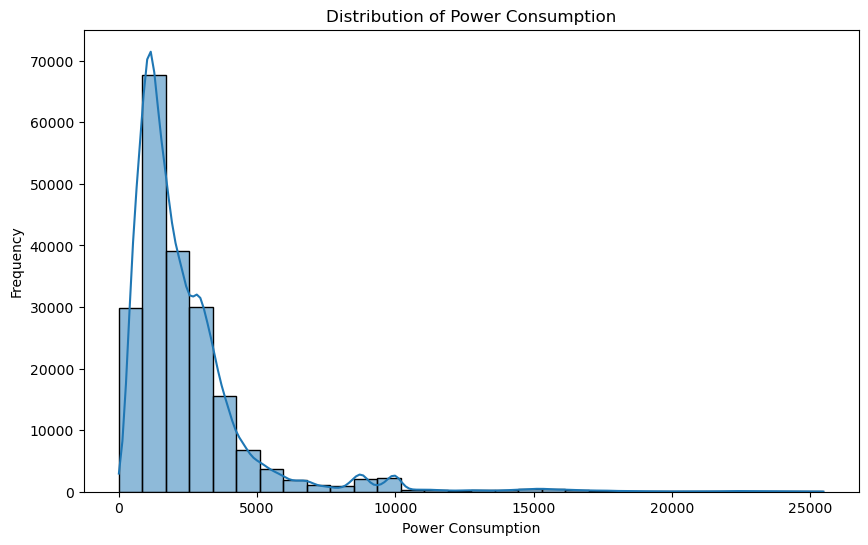

In [89]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['power_consumption'], bins=30, kde=True)
plt.title('Distribution of Power Consumption')
plt.xlabel('Power Consumption')
plt.ylabel('Frequency')
plt.show()

In [90]:
# 년기준 일 평균 소비전력
train_df['day_of_year'] = train_df['date_time'].dt.dayofyear
mean_power_by_day_of_year = train_df.groupby('day_of_year')['power_consumption'].mean()
# 년기준 시간평균 소비전력
train_df['hour_of_year'] = train_df['date_time'].dt.hour + (train_df['date_time'].dt.dayofyear - 1) * 24
mean_power_by_hour_of_year = train_df.groupby('hour_of_year')['power_consumption'].mean()

# 년기준 월평균 소비전력
mean_power_by_month = train_df.groupby('month')['power_consumption'].mean()

# 일기준 시간 평균 소비전력
mean_power_by_hour = train_df.groupby('hour')['power_consumption'].mean()

# 월기준 시간 평균 소비전력
mean_power_by_day = train_df.groupby('day')['power_consumption'].mean()

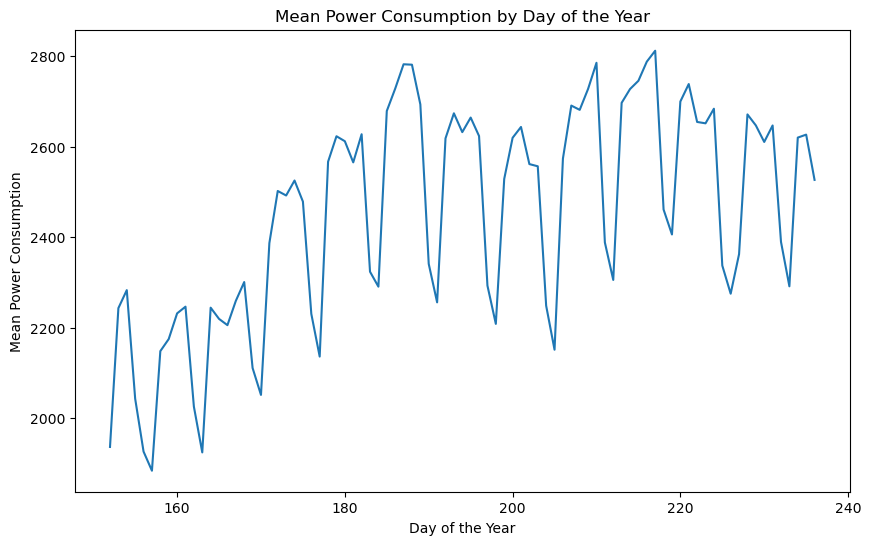

In [91]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=mean_power_by_day_of_year.index, y=mean_power_by_day_of_year.values)
plt.title('Mean Power Consumption by Day of the Year')
plt.xlabel('Day of the Year')
plt.ylabel('Mean Power Consumption')
plt.show()

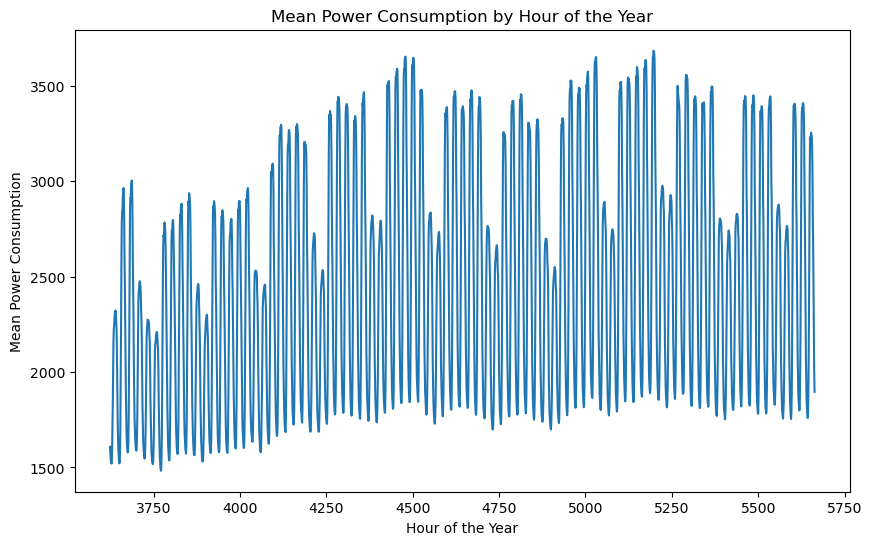

In [92]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=mean_power_by_hour_of_year.index, y=mean_power_by_hour_of_year.values)
plt.title('Mean Power Consumption by Hour of the Year')
plt.xlabel('Hour of the Year')
plt.ylabel('Mean Power Consumption')
plt.show()

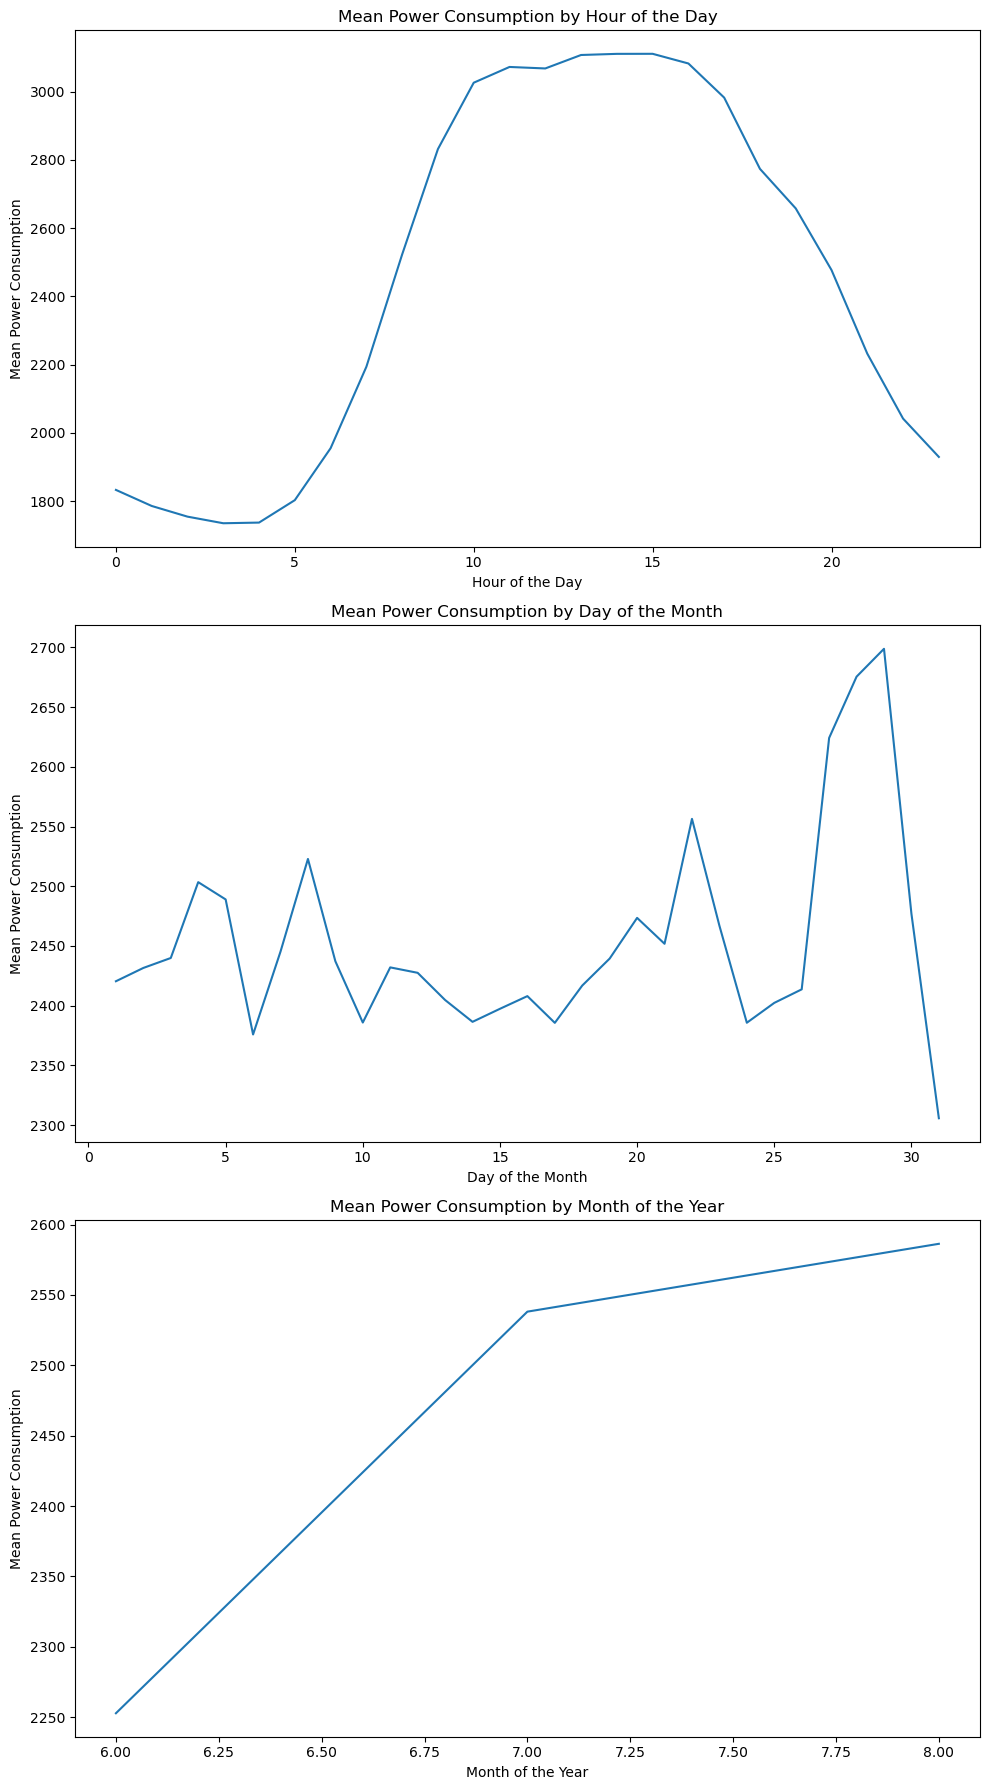

In [93]:
fig, axs = plt.subplots(3, 1, figsize=(10, 18))

# Plot mean power consumption by hour of the day
sns.lineplot(x=mean_power_by_hour.index, y=mean_power_by_hour.values, ax=axs[0])
axs[0].set_title('Mean Power Consumption by Hour of the Day')
axs[0].set_xlabel('Hour of the Day')
axs[0].set_ylabel('Mean Power Consumption')

# Plot mean power consumption by day of the month
sns.lineplot(x=mean_power_by_day.index, y=mean_power_by_day.values, ax=axs[1])
axs[1].set_title('Mean Power Consumption by Day of the Month')
axs[1].set_xlabel('Day of the Month')
axs[1].set_ylabel('Mean Power Consumption')

# 년기준 월평균 소비전력
sns.lineplot(x=mean_power_by_month.index, y=mean_power_by_month.values, ax=axs[2])
axs[2].set_title('Mean Power Consumption by Month of the Year')
axs[2].set_xlabel('Month of the Year')
axs[2].set_ylabel('Mean Power Consumption')

plt.tight_layout()
plt.show()

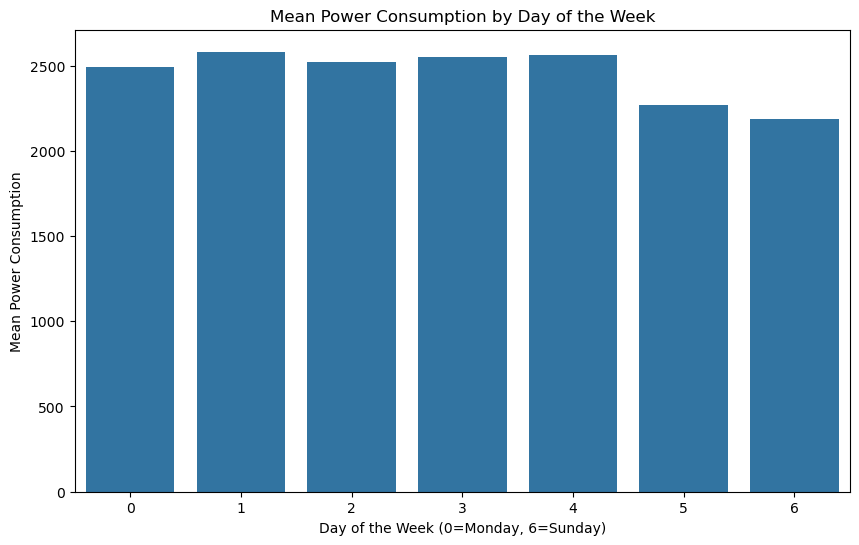

In [94]:
train_df['day_of_week'] = train_df['date_time'].dt.dayofweek

# 요일별 전력평균
mean_power_by_day_of_week = train_df.groupby('day_of_week')['power_consumption'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_power_by_day_of_week.index, y=mean_power_by_day_of_week.values)
plt.title('Mean Power Consumption by Day of the Week')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Mean Power Consumption')
plt.show()

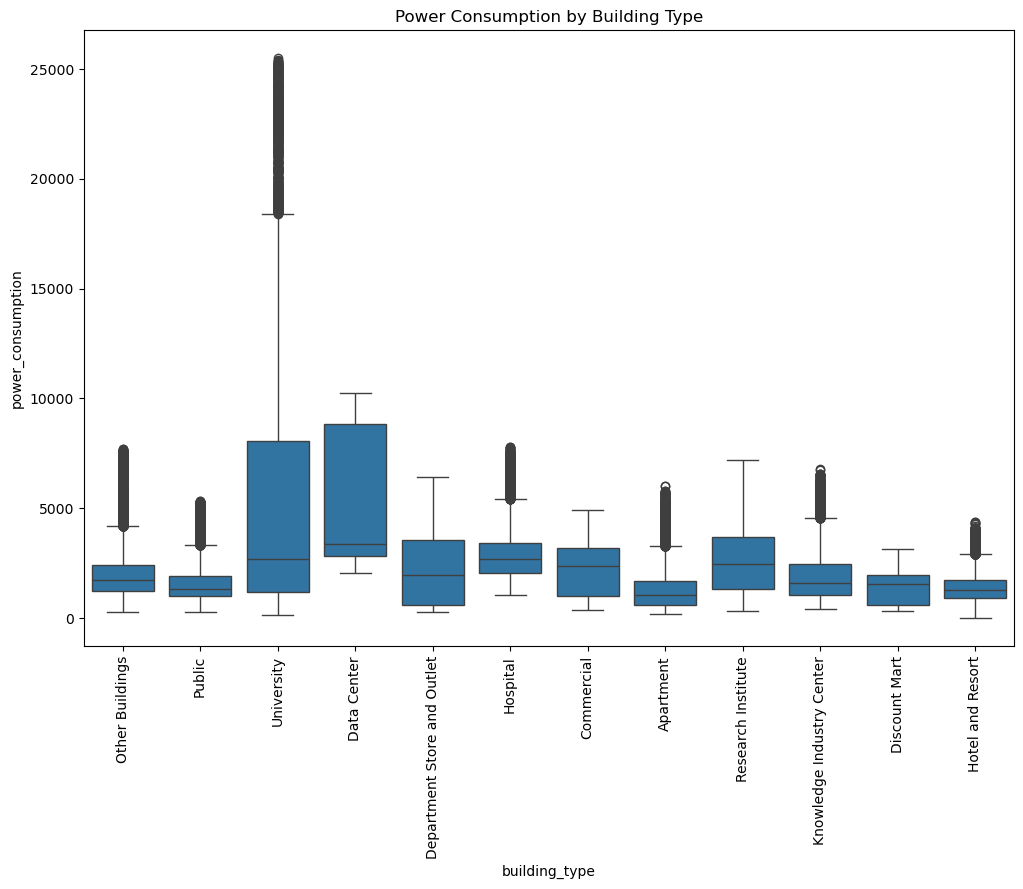

In [95]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='building_type', y='power_consumption', data=train_df)
plt.title('Power Consumption by Building Type')
plt.xticks(rotation=90)
plt.show()

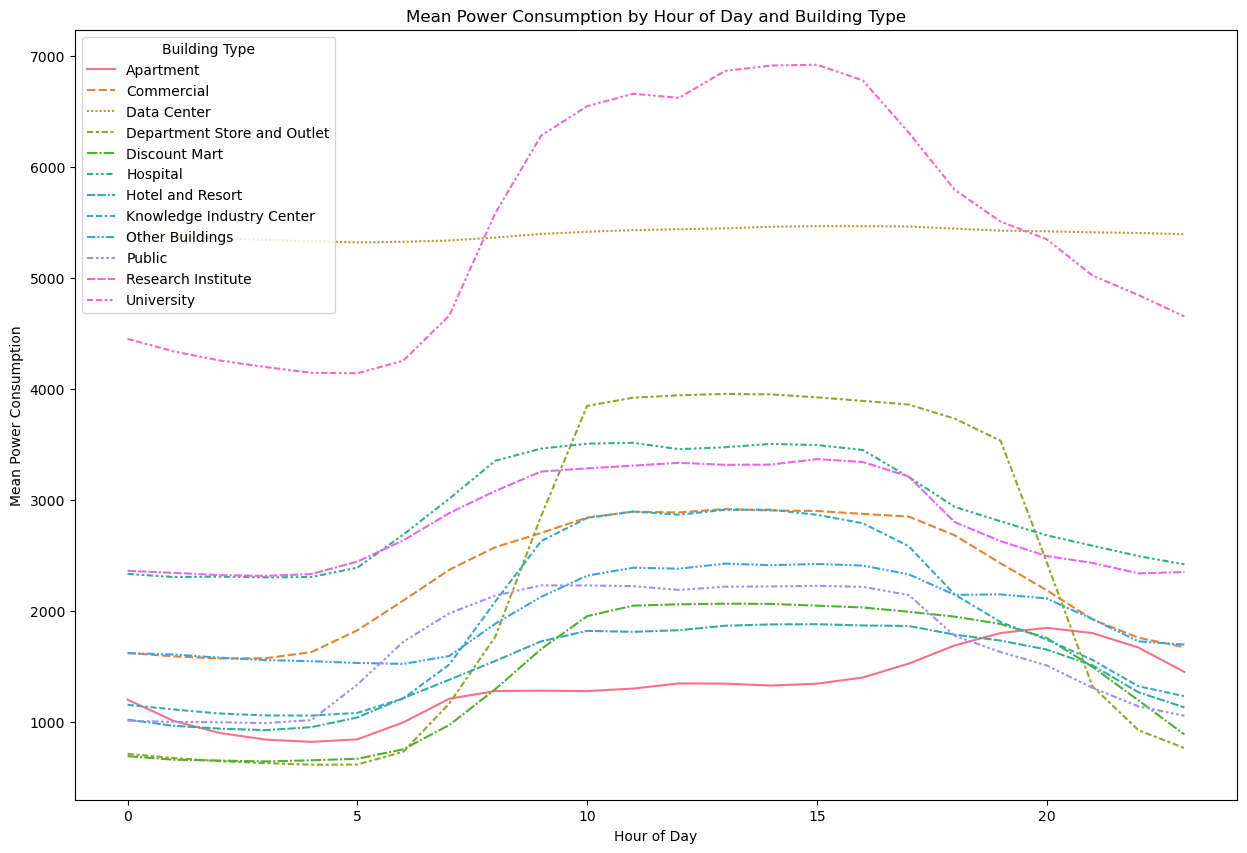

In [96]:
mean_power_by_hour_building = train_df.groupby(['hour', 'building_type'])['power_consumption'].mean().reset_index()

pivot_df = mean_power_by_hour_building.pivot(index='hour', columns='building_type', values='power_consumption')

plt.figure(figsize=(15, 10))
sns.lineplot(data=pivot_df)
plt.title('Mean Power Consumption by Hour of Day and Building Type')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Power Consumption')
plt.legend(title='Building Type')
plt.show()

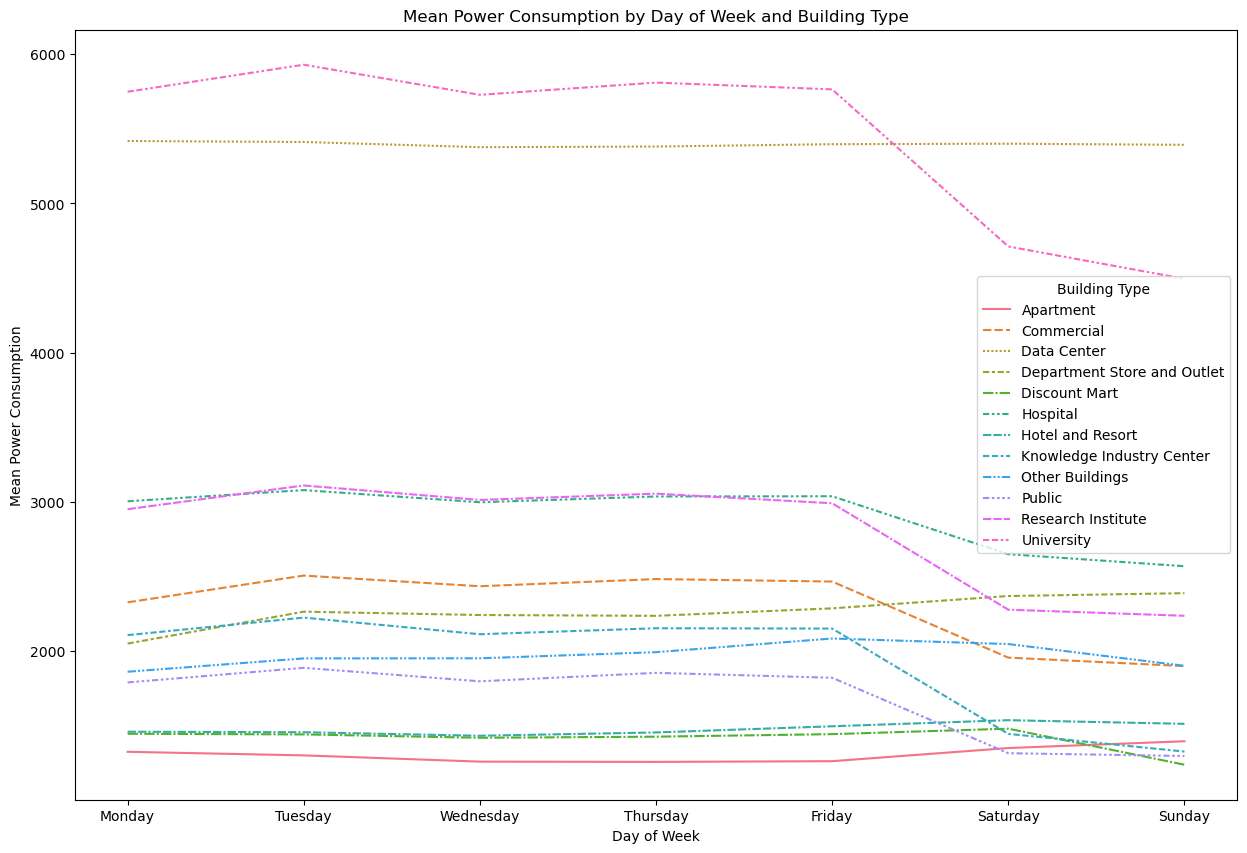

In [97]:
mean_power_by_day_building = train_df.groupby(['day_of_week', 'building_type'])['power_consumption'].mean().reset_index()

pivot_df_day = mean_power_by_day_building.pivot(index='day_of_week', columns='building_type', values='power_consumption')

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_df_day.index = day_names

plt.figure(figsize=(15, 10))
sns.lineplot(data=pivot_df_day)
plt.title('Mean Power Consumption by Day of Week and Building Type')
plt.xlabel('Day of Week')
plt.ylabel('Mean Power Consumption')
plt.legend(title='Building Type')
plt.show()

### 추가 EDA
---

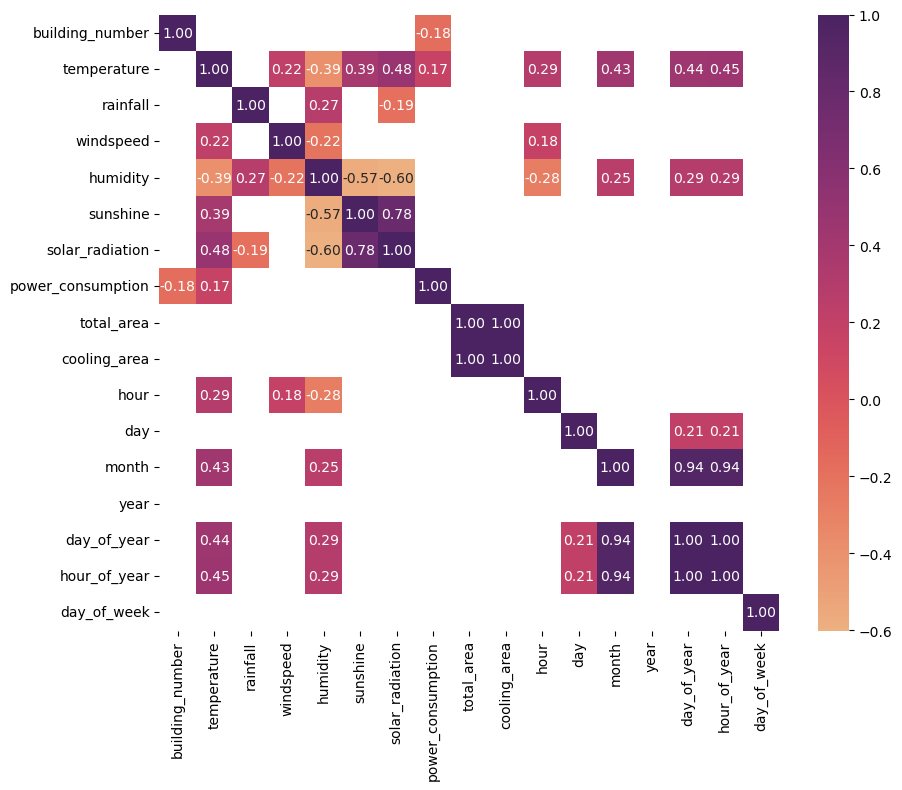

In [180]:
cor_matrix = train_df.corr(numeric_only=True)
mask = abs(cor_matrix) <= 0.15

plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap="flare", mask=mask)
plt.show()


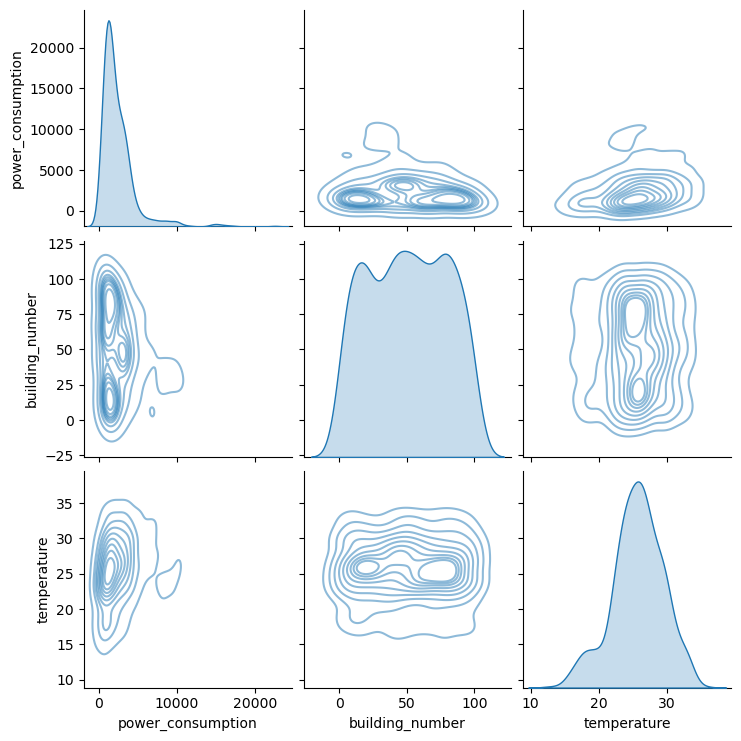

In [184]:
pairplot_cols = ['power_consumption', 'building_number', 'temperature']
sample_df = train_df[pairplot_cols].sample(n=1000, random_state=42)
sns.pairplot(sample_df, kind='kde', plot_kws={'alpha': 0.5})
plt.show()

power_comsumption과 상관관계를 가지는 변수: building_number, temperature

---
### 1등 코드 

In [98]:
import os
import sys
import math
import optuna
import platform
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor

from datetime import datetime
from tqdm import tqdm
from sktime.forecasting.model_selection import temporal_train_test_split

In [99]:
base_path = './'

In [100]:
def SMAPE(true, pred):
    return np.mean((np.abs(true-pred))/(np.abs(true) + np.abs(pred))) * 200

def weighted_mse(alpha = 1):
    def weighted_mse_fixed(label, pred):
        residual = (label - pred).astype("float")
        grad = np.where(residual>0, -2*alpha*residual, -2*residual)
        hess = np.where(residual>0, 2*alpha, 2.0)
        return grad, hess
    return weighted_mse_fixed

In [101]:
def add_data(df):
    for i in range(2):
        np.random.seed(i)
        num_rows = len(df)
        random_factors = ['temp', 'prec', 'wind', 'hum']

        random_data = {
            factor: df[factor] * np.random.uniform(0.9, 1.1, num_rows)
            for factor in random_factors
        }

        random_data = {factor: np.round(data, 1) for factor, data in random_data.items()}

        new_df = df.copy()
        new_df.update(pd.DataFrame(random_data))
        df = pd.concat([df, new_df], ignore_index=True)

    df = df.sort_values(by=['building', 'date_time']).reset_index(drop=True)
    
    return df

In [102]:
def weather(train):
    condition = train['prec'] > 0
    filtered_df = train[condition].index.tolist()
    train['weather'] = 0

    for idx in filtered_df:
        for offset in range(-3, 4):
            new_idx = idx + offset
            if 0 <= new_idx < len(train):
                train.loc[new_idx, 'weather'] = 1
                
    return train

In [103]:
def time_features(data, mode):
    date = pd.to_datetime(data.date_time)
    
    data['hour'] = date.dt.hour
    data['dow'] = date.dt.weekday
    data['month'] = date.dt.month
    data['week'] = date.dt.isocalendar().week.astype(np.int32)
    data['day'] = date.dt.day

    data['sin_time'] = np.sin(2 * np.pi * data['hour'] / 24)
    data['cos_time'] = np.cos(2 * np.pi * data['hour'] / 24)
    
    data['holiday'] = data.apply(lambda x : 0 if x['dow'] < 5 else 1, axis = 1)
    data['date'] = pd.to_datetime(data['date_time'], format='%Y%m%d %H').dt.date
    
    building_dates = [['2022-06-07', '2022-06-17'], ['2022-07-31', '2022-07-23', '2022-07-20'], ['2022-08-16', '2022-08-17']]
    
    for index, b in enumerate([2, 3 ,54]):
        data.loc[data['building'] == b, 'holiday'] = 0
        data.loc[(data['building'] == b) & (data['dow'] == 0) , 'holiday'] = 1
        data.loc[(data['building'] == b) & (data['date'].isin([pd.to_datetime(i).date() for i in building_dates[index]])), 'holiday'] = 1
    
    data.loc[(data['building'] != 14) & (data['date'].isin([pd.to_datetime(i).date() for i in ['2022-06-01', '2022-06-06', '2022-08-15']])), 'holiday'] = 1
    data.loc[(data['building'] == 14) & (data['date'].isin([pd.to_datetime(i).date() for i in ['2022-06-14']])) , 'holiday'] = 1
    data.loc[data['building'] == 85, 'holiday'] = 0
    
    def week_of_month(date):
        first_day = date.replace(day=1)
        if (date.isocalendar().week - first_day.isocalendar().week + 1) % 2 == 0:
            if date.weekday() == 6:
                return 1
        return 0

    data['week_of_month'] = data['date'].apply(week_of_month)

    target_buildings = [87,88,89,90,91,92]
    data.loc[(data['building'].isin(target_buildings)) , 'holiday'] = 0
    data.loc[(data['building'].isin(target_buildings)) & (data['week_of_month'] == 1), 'holiday'] = 1
    
    building_dates = [['2022-06-20', '2022-07-11', '2022-08-08', '2022-06-17'], ['2022-06-13', '2022-07-25', '2022-08-01'],
        ['2022-07-18', '2022-08-08'], ['2022-06-20', '2022-07-18', '2022-06-17', '2022-08-08'],
        ['2022-06-27', '2022-07-25', '2022-08-08'], ['2022-06-13', '2022-07-11', '2022-08-22'],
        ['2022-06-10', '2022-08-10', '2022-07-10', '2022-07-24', '2022-06-26', '2022-08-28']]
    
    if mode == 'byb' or mode == 'gu_byb':
        for index, b in enumerate([37,38,39,40,41,42,86]):
            data.loc[data['building'] == b, 'holiday'] = 0
            data.loc[(data['building'] == b) & (data['date'].isin([pd.to_datetime(i).date() for i in building_dates[index]])), 'holiday'] = 1
            
    if mode == 'all' or mode == 'gu_all':
        data.loc[data['building'] == 86, 'holiday'] = 0
        data.loc[(data['building'] == 86) & (data['date'].isin([pd.to_datetime(i).date() for i in building_dates[-1]+['2022-07-30']])), 'holiday'] = 1
    
    data['date'] = pd.to_datetime(data['date_time'], format='%Y%m%d %H')
    
    return data

In [104]:
def side_indicator(data):
    data['THI'] = 9/5*data['temp'] - 0.55*(1-data['hum']/100)*(9/5*data['hum']-26)+32
    data['WC']=13.12+0.6215*data['temp']-13.947*data['wind']**0.16+0.486*data['temp']*data['wind']**0.16
    
    def calculate_cdh(xs):
        ys = []
        for i in range(len(xs)):
            if i < 11:
                ys.append(np.sum(xs[:(i+1)] - 26))
            else:
                ys.append(np.sum(xs[(i-11):(i+1)] - 26))
        return np.array(ys)

    cdhs = []
    for num in range(1, 101):
        temp = data[data['building'] == num]
        cdh = calculate_cdh(temp['temp'].values)
        cdhs.extend(cdh)
    data['CDH'] = cdhs

    return data

In [105]:
def summer_cos(date):
    start_date = datetime.strptime("2022-06-01 00:00:00", "%Y-%m-%d %H:%M:%S")
    end_date = datetime.strptime("2022-09-14 00:00:00", "%Y-%m-%d %H:%M:%S")

    period = (end_date - start_date).total_seconds()

    return math.cos(2 * math.pi * (date - start_date).total_seconds() / period)


In [106]:
def summer_sin(date):
    start_date = datetime.strptime("2022-06-01 00:00:00", "%Y-%m-%d %H:%M:%S")
    end_date = datetime.strptime("2022-09-14 00:00:00", "%Y-%m-%d %H:%M:%S")

    period = (end_date - start_date).total_seconds()

    return math.sin(2 * math.pi * (date - start_date).total_seconds() / period)


In [107]:
def temp_features(data):
    avg_temp = pd.pivot_table(data[data['hour']%3 == 0], values = 'temp', index = ['building', 'day', 'month'], aggfunc = np.mean).reset_index()
    avg_temp.rename(columns={'temp': 'avg_temp'}, inplace=True)
    data = pd.merge(data, avg_temp, on=['building', 'day', 'month'], how='left')
    
    max_temp = pd.pivot_table(data, values = 'temp', index = ['building', 'day', 'month'], aggfunc = np.max).reset_index()
    max_temp.rename(columns={'temp': 'max_temp'}, inplace=True)
    data = pd.merge(data, max_temp, on=['building', 'day', 'month'], how='left')
    
    min_temp = pd.pivot_table(data, values = 'temp', index = ['building', 'day', 'month'], aggfunc = np.min).reset_index()
    min_temp.rename(columns={'temp': 'min_temp'}, inplace=True)
    data = pd.merge(data, min_temp, on=['building', 'day', 'month'], how='left')
    
    data['temp_diff'] = data['max_temp'] - data['min_temp']
    
    return data

In [108]:
def process_data(data, mode):
    data['wind'] = data['wind'].fillna(method='ffill')
    data['hum'] = data['hum'].fillna(method='ffill')
    data = data.fillna(0)

    data = time_features(data, mode)
    data = side_indicator(data)
    data = temp_features(data)
    
    data['summer_cos'] = data['date'].apply(summer_cos)
    data['summer_sin'] = data['date'].apply(summer_sin)

    return data

In [109]:
def mean_std(train, test, mode):
    ratio = np.array([0.985]+[0.98]*2+[0.995]*2+[0.99]*2)
    if mode == 'byb':
        train['target'] = train.apply(lambda row: row['target'] * ratio[row['dow']], axis=1)
    elif mode == 'all':
        ratio -= 0.005
        train['target'] = train.apply(lambda row: row['target'] * ratio[row['dow']], axis=1)
    
    power_mean = pd.pivot_table(train, values = 'target', index = ['building', 'hour', 'dow'], aggfunc = np.mean).reset_index()
    power_mean.rename(columns={'target': 'dow_hour_mean'}, inplace=True)
    train = pd.merge(train, power_mean, on=['building', 'hour', 'dow'], how='left')
    test = pd.merge(test, power_mean, on=['building', 'hour', 'dow'], how='left')
    
    power_holiday_mean = pd.pivot_table(train, values = 'target', index = ['building', 'hour', 'holiday'], aggfunc = np.mean).reset_index()
    power_holiday_mean.rename(columns={'target': 'holiday_mean'}, inplace=True)
    train = pd.merge(train, power_holiday_mean, on=['building', 'hour', 'holiday'], how='left')
    test = pd.merge(test, power_holiday_mean, on=['building', 'hour', 'holiday'], how='left')

    power_holiday_std = pd.pivot_table(train, values = 'target', index = ['building', 'hour', 'holiday'], aggfunc = np.std).reset_index()
    power_holiday_std.rename(columns={'target': 'holiday_std'}, inplace=True)
    train = pd.merge(train, power_holiday_std, on=['building', 'hour', 'holiday'], how='left')
    test = pd.merge(test, power_holiday_std, on=['building', 'hour', 'holiday'], how='left')

    power_hour_mean = pd.pivot_table(train, values = 'target', index = ['building', 'hour',], aggfunc = np.mean).reset_index()
    power_hour_mean.rename(columns={'target': 'hour_mean'}, inplace=True)
    train = pd.merge(train, power_hour_mean, on=['building', 'hour', ], how='left')
    test = pd.merge(test, power_hour_mean, on=['building', 'hour', ], how='left')

    power_hour_std = pd.pivot_table(train, values = 'target', index = ['building', 'hour',], aggfunc = np.std).reset_index()
    power_hour_std.rename(columns={'target': 'hour_std'}, inplace=True)
    train = pd.merge(train, power_hour_std, on=['building', 'hour', ], how='left')
    test = pd.merge(test, power_hour_std, on=['building', 'hour', ], how='left')
    
    if mode == 'all' or mode == 'gu_all':
        train['date'] = pd.to_datetime(train['date_time'], format='%Y%m%d %H').dt.date
        test['date'] = pd.to_datetime(test['date_time'], format='%Y%m%d %H').dt.date
        building_dates = [['2022-06-20', '2022-07-11', '2022-08-08', '2022-06-17'], ['2022-06-13', '2022-07-25', '2022-08-01'],
            ['2022-07-18', '2022-08-08'], ['2022-06-20', '2022-07-18', '2022-06-17', '2022-08-08'],
            ['2022-06-27', '2022-07-25', '2022-08-08'], ['2022-06-13', '2022-07-11', '2022-08-22']]

        for index, b in enumerate([37,38,39,40,41,42]):
            train.loc[train['building'] == b, 'holiday'] = 0
            train.loc[(train['building'] == b) & (train['date'].isin([pd.to_datetime(i).date() for i in building_dates[index]])), 'holiday'] = 1
            test.loc[test['building'] == b, 'holiday'] = 0
            test.loc[(test['building'] == b) & (test['date'].isin([pd.to_datetime(i).date() for i in building_dates[index]])), 'holiday'] = 1
    
    return train, test

In [110]:
def process_info(data, is_train=True):
    data.columns = ['building', 'type', 'all_area', 'cool_area', 'sun']
    data['sun'] = data['sun'].replace('-', 0).astype('float')

    value_dict = {value: index for index, value in enumerate(data['type'].unique())}
    data['type'] = data['type'].map(value_dict)
    
    filtered_data = data[(data['type'] == 7) & (data['cool_area'] != 0)]
    result = (filtered_data['all_area'].iloc[1:].sum() / filtered_data['cool_area'].iloc[1:].sum())
    condition = (data['type'] == 7) & (data['cool_area'] == 0)
    data.loc[condition, 'cool_area'] = (data.loc[condition, 'all_area'] / result).astype('int')
    
    filtered_data = data[(data['type'] == 9) & (data['cool_area'] > 500)]
    result = (filtered_data['all_area'].sum() / filtered_data['cool_area'].sum())
    condition = (data['type'] == 9) & (data['cool_area'] < 500)
    data.loc[condition, 'cool_area'] = round(data.loc[condition, 'all_area'] / result, 1)
    
    return data

In [111]:
def get_train_and_test_data(mode):
    building_info = pd.read_csv(os.path.join(base_path,'building_info.csv')).drop(['ESS저장용량(kWh)', 'PCS용량(kW)'], axis=1)
    building_info = process_info(building_info)

    train_data = pd.read_csv(os.path.join(base_path,'train.csv')).drop(['일조(hr)', '일사(MJ/m2)'], axis=1)
    train_data.columns = ['num_date_time', 'building', 'date_time', 'temp', 'prec', 'wind', 'hum', 'target']
    train_data = process_data(train_data, mode)

    test_data = pd.read_csv(os.path.join(base_path,'test.csv'))
    test_data.columns = ['num_date_time', 'building', 'date_time', 'temp', 'prec', 'wind', 'hum']
    test_data = process_data(test_data, mode)
    
    train_data, test_data = mean_std(train_data, test_data, mode)
    
    if mode == 'all' or mode == 'gu_all':
        train_data = train_data.merge(building_info, on='building', how='left')
        test_data = test_data.merge(building_info, on='building', how='left')
        
    return train_data, test_data

In [112]:
gu_byb = ['num_date_time', 'building', 'date_time', 'temp', 'wind', 'hum',
    'dow', 'month', 'week', 'dow_hour_mean', 'holiday',
    'holiday_mean', 'holiday_std', 'hour_mean', 'hour_std', 'sin_time',
    'cos_time', 'THI', 'WC', 'CDH', 'target']

train, test = get_train_and_test_data('gu_byb')

/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['wind'] = data['wind'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['hum'] = data['hum'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/1636497138.py:2: FutureWarning: The provided callable <function mean at 0x107720400> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avg_temp = pd.pivot_table(data[data['hour']%3 == 0], values = 'temp', index = ['building', 'day', 'month'], aggfunc = np.mean).reset_index(

In [114]:
train = train[gu_byb]
test = test[gu_byb[:-1]]

In [115]:
scores = []  
best_it = [] 

In [116]:
score = pd.DataFrame({'building':range(1,101)})
for i in tqdm(range(100)):
    y = train.loc[train.building == i+1, 'target']
    x = train.loc[train.building == i+1, ].iloc[:, 3:].drop(['target'], axis=1)
    y_train, y_valid, x_train, x_valid = temporal_train_test_split(y = y, X = x, test_size = 168)
    
    xgb = XGBRegressor(colsample_bytree=0.8, eta=0.01, max_depth=5,
        min_child_weight=6,n_estimators=2000, subsample=0.9, early_stopping_rounds=50, eval_metric=SMAPE)
    
    xgb.set_params(**{'objective':weighted_mse(100)})
    
    xgb.fit(x_train, y_train, eval_set=[(x_train, y_train), 
                                            (x_valid, y_valid)], verbose=False)
    
    y_pred = xgb.predict(x_valid)  
            
    sm = SMAPE(y_valid, y_pred)
    scores.append(sm)
    best_it.append(xgb.best_iteration+1) 

100%|██████████| 100/100 [00:55<00:00,  1.80it/s]


In [117]:
score['score'] = scores
print(sum(scores)/len(scores)) 
print(sum(best_it)/len(best_it))

4.423843550815071
450.08


In [118]:
preds = np.array([]) 

for i in tqdm(range(100)):
    pred_df = pd.DataFrame()   
    
    for seed in [0,1,2,3,4]: 
        y_train = train.loc[train.building == i+1, 'target']
        x_train = train.loc[train.building == i+1, ].iloc[:, 3:].drop(['target'], axis=1)
        x_test = test.loc[test.building == i+1, ].iloc[:,3:]
        
        xgb = XGBRegressor(colsample_bytree=0.8, eta=0.01, max_depth=5, seed=seed,
            min_child_weight=6,n_estimators=best_it[i], subsample=0.9)

        xgb.fit(x_train, y_train)
        y_pred = xgb.predict(x_test)
        pred_df.loc[:,seed] = y_pred   
        
    pred = pred_df.mean(axis=1)        
    preds = np.append(preds, pred)   

100%|██████████| 100/100 [02:02<00:00,  1.22s/it]


In [119]:
submission = pd.read_csv(os.path.join(base_path,'sample_submission.csv'))
submission['answer'] = preds
submission.to_csv('./gu_byb.csv', index = False)

del train, test, scores, best_it, submission

In [120]:
train, test = get_train_and_test_data('gu_all')

/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['wind'] = data['wind'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['hum'] = data['hum'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/1636497138.py:2: FutureWarning: The provided callable <function mean at 0x107720400> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avg_temp = pd.pivot_table(data[data['hour']%3 == 0], values = 'temp', index = ['building', 'day', 'month'], aggfunc = np.mean).reset_index(

In [121]:
colsample_bytree = [0.9,0.9,0.8,0.9,0.9]
gamma = [8.161415, 8.915918, 8.249356, 6.575258, 8.487247]
max_depth = [6,5,6,6,6]
min_child_weight = [47,8,30,54,77]
reg_alpha = [6.721675, 6.736361, 7.109872, 7.016596, 6.186162]
reg_lambda = [6.064121, 5.957454, 5.927528, 5.413840, 4.798086]
subsample = [1.0,1.0,1.0,1.0,1.0]
value = [5.010795, 5.016419, 5.017388, 5.023210, 5.028135]

In [122]:
df = pd.DataFrame({'params_colsample_bytree':colsample_bytree, 'params_gamma':gamma, 'params_max_depth':max_depth, 'params_min_child_weight':min_child_weight,
    'params_reg_alpha':reg_alpha, 'params_reg_lambda':reg_lambda, 'params_subsample':subsample, 'value':value})

In [123]:
gu_all = ['num_date_time', 'building', 'date_time', 'temp', 'wind', 'hum',
    'type', 'all_area', 'cool_area', 'dow', 'month', 'week',
    'dow_hour_mean', 'date', 'holiday', 'holiday_mean', 'holiday_std',
    'hour_mean', 'hour_std', 'sin_time', 'cos_time', 'THI', 'WC', 'CDH', 'target']

In [124]:
train, test = train[gu_all], test[gu_all[:-1]]

In [125]:
train['date'] = pd.to_datetime(train['date'])
train['building'] = train['building'].astype('category')
train['type'] = train['type'].astype('category')

In [ ]:
x_train = train[train['date'] < f'2022-08-18'].drop(['num_date_time', 'date_time', 'target', 'date'], axis=1).reset_index(drop=True)
x_valid = train[train['date'] >= f'2022-08-18'].drop(['num_date_time', 'date_time', 'target', 'date'], axis=1).reset_index(drop=True)

y_train = train[train['date'] < f'2022-08-18']['target'].reset_index(drop=True)
y_valid = train[train['date'] >= f'2022-08-18']['target'].reset_index(drop=True)

In [128]:
import xgboost as xgb

dtrain = xgb.DMatrix(data=x_train, label=y_train, enable_categorical=True)
dvalid = xgb.DMatrix(data=x_valid, label=y_valid, enable_categorical=True)

In [129]:
param = {
    'reg_lambda': df['params_reg_lambda'][0] ,
    'gamma': df['params_gamma'][0],
    'reg_alpha': df['params_reg_alpha'][0] ,
    'colsample_bytree': df['params_colsample_bytree'][0] ,
    'subsample': df['params_subsample'][0] ,
    'max_depth': df['params_max_depth'][0],
    'min_child_weight': df['params_min_child_weight'][0],
}

In [130]:
model = xgb.train(params=param, dtrain=dtrain, num_boost_round=1000,
    evals=[(dvalid, 'valid')], early_stopping_rounds=100, verbose_eval=False)

preds = model.predict(dvalid)
smape = SMAPE(y_valid, preds)

In [131]:
best_it = model.best_iteration+1
building_score = []
for i in range(100):
    building_score.append(SMAPE(y_valid[i*168:(i+1)*168], preds[i*168:(i+1)*168]))

In [132]:
score['score_all'] = building_score
score.to_csv('./score.csv', index=False)
print(smape, best_it)

5.098067200333231 159


In [133]:
preds = np.array([])

test = test.copy()
test['date'] = pd.to_datetime(test['date'])
test['building'] = test['building'].astype('category')
test['type'] = test['type'].astype('category')

In [134]:
x_train = train.drop(['num_date_time', 'date_time', 'target', 'date'], axis=1)
x_test = test.drop(['num_date_time', 'date_time', 'date'], axis=1)
y_train = train['target']

In [135]:
dtrain = xgb.DMatrix(data=x_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(data=x_test, enable_categorical=True)

In [136]:
pred_df = pd.DataFrame()   

for seed in tqdm(range(5)):
    param = {
        'reg_lambda': df['params_reg_lambda'][0] ,
        'gamma': df['params_gamma'][0],
        'reg_alpha': df['params_reg_alpha'][0] ,
        'colsample_bytree': df['params_colsample_bytree'][0] ,
        'subsample': df['params_subsample'][0] ,
        'max_depth': df['params_max_depth'][0],
        'min_child_weight': df['params_min_child_weight'][0],
        'seed':seed,
    }

    model = xgb.train(params=param, dtrain=dtrain, num_boost_round=best_it)

    y_pred = model.predict(dtest)
    pred_df.loc[:,seed] = y_pred   

100%|██████████| 5/5 [00:03<00:00,  1.43it/s]


In [137]:
pred = pred_df.mean(axis=1)        
preds = np.append(preds, pred)   

In [138]:
submission = pd.read_csv(os.path.join(base_path,'sample_submission.csv'))
submission['answer'] = preds
submission.to_csv('./gu_all.csv', index = False)

In [139]:
byb = ['num_date_time', 'building', 'date_time', 'temp', 'wind', 'hum',
    'dow', 'month', 'week', 'dow_hour_mean', 'holiday',
    'holiday_mean', 'holiday_std', 'hour_mean', 'hour_std', 'sin_time',
    'cos_time', 'THI', 'WC', 'CDH', 'summer_cos', 'summer_sin', 'target']

In [140]:
train, test = get_train_and_test_data('byb')
train, test = train[byb], test[byb[:-1]]

/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['wind'] = data['wind'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['hum'] = data['hum'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/1636497138.py:2: FutureWarning: The provided callable <function mean at 0x107720400> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avg_temp = pd.pivot_table(data[data['hour']%3 == 0], values = 'temp', index = ['building', 'day', 'month'], aggfunc = np.mean).reset_index(

In [141]:
scores = []   
best_it = []  

for b in tqdm(range(100)):
    y = train.loc[train.building == b+1, 'target']
    x = train.loc[train.building == b+1, ].iloc[:, 3:].drop(['target'], axis=1)
    y_train, y_valid, x_train, x_valid = temporal_train_test_split(y = y, X = x, test_size = 168)
    
    xgb = XGBRegressor(colsample_bytree=0.8, eta=0.1, max_depth=5,
        min_child_weight=6,n_estimators=1000, subsample=0.9, early_stopping_rounds=50)
    
    xgb.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)
    
    y_pred = xgb.predict(x_valid)  

            
    sm = SMAPE(y_valid, y_pred)
    scores.append(sm)
    best_it.append(xgb.best_iteration+1) 

100%|██████████| 100/100 [00:10<00:00,  9.23it/s]


In [142]:
print(sum(scores)/len(scores)) 
print(sum(best_it)/len(best_it))

5.2728844676209
91.17


In [143]:
preds = np.array([]) 

for i in tqdm(range(100)):
    pred_df = pd.DataFrame()   
    
    for seed in [0,1,2,3,4,5,6,7,8,9,10]: 
        y_train = train.loc[train.building == i+1, 'target']
        x_train = train.loc[train.building == i+1, ].iloc[:, 3:].drop(['target'], axis=1)
        x_test = test.loc[test.building == i+1, ].iloc[:,3:]
        
        xgb = XGBRegressor(colsample_bytree=0.8, eta=0.1, max_depth=5, seed=seed,
            min_child_weight=6,n_estimators=best_it[i], subsample=0.9)
        
        xgb.fit(x_train, y_train)
        y_pred = xgb.predict(x_test)
        pred_df.loc[:,seed] = y_pred   
        
    pred = pred_df.mean(axis=1)        
    preds = np.append(preds, pred) 

100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


In [144]:
submission = pd.read_csv(os.path.join(base_path,'sample_submission.csv'))
submission['answer'] = preds
submission.to_csv('./byb.csv', index = False)
submission

,num_date_time,answer
0,1_20220825 00,1935.136230
1,1_20220825 01,1934.544922
2,1_20220825 02,1713.614746
3,1_20220825 03,1603.310425
4,1_20220825 04,1652.050415
...,...,...
16795,100_20220831 19,810.434204
16796,100_20220831 20,756.584229
16797,100_20220831 21,682.061523
16798,100_20220831 22,560.776978


In [145]:
del train, test, scores, best_it, submission

In [147]:
data = [
    [61, 61, 4.946742, '2023-08-18 11:59:30.066695', '2023-08-18 12:01:19.655572', '0 days 00:01:49.588877', 0.7, 0.695975, 6, 43, 6.357773, 2.568356, 1.0, 'COMPLETE'],
    [23, 23, 4.950789, '2023-08-18 11:24:36.282096', '2023-08-18 11:25:56.779154', '0 days 00:01:20.497058', 0.7, 0.023800, 6, 30, 6.278440, 1.460707, 1.0, 'COMPLETE'],
    [14, 14, 4.975757, '2023-08-18 11:16:59.783126', '2023-08-18 11:18:02.962945', '0 days 00:01:03.179819', 0.7, 0.966742, 6, 36, 3.762862, 0.362957, 1.0, 'COMPLETE'],
    [51, 51, 4.986851, '2023-08-18 11:51:40.355474', '2023-08-18 11:52:48.657127', '0 days 00:01:08.301653', 0.7, 1.034617, 6, 49, 5.606792, 1.690612, 1.0, 'COMPLETE'],
    [31, 31, 4.994619, '2023-08-18 11:32:34.984062', '2023-08-18 11:33:29.901314', '0 days 00:00:54.917252', 0.7, 0.094354, 6, 36, 5.006265, 1.527805, 1.0, 'COMPLETE'],
    [71, 71, 5.450572, '2023-08-14 13:17:40.337706', '2023-08-14 13:20:33.336589', '0 days 00:02:52.998883', 1.0, 4.632731, 6, 18, 2.979220, 7.641126, 0.7, 'COMPLETE'],
    [11, 11, 5.451309, '2023-08-14 11:00:11.878935', '2023-08-14 11:02:55.559494', '0 days 00:02:43.680559', 0.9, 8.375491, 6, 1, 4.829945, 7.857255, 0.7, 'COMPLETE'],
    [32, 32, 5.451501, '2023-08-14 11:48:49.899305', '2023-08-14 11:51:31.199312', '0 days 00:02:41.300007', 0.9, 4.436363, 6, 1, 3.906413, 6.982815, 0.7, 'COMPLETE'],
    [21, 21, 5.451785, '2023-08-14 11:22:30.440656', '2023-08-14 11:25:13.331292', '0 days 00:02:42.890636', 0.9, 3.917213, 6, 3, 4.037673, 8.432115, 0.7, 'COMPLETE'],
    [89, 89, 5.451788, '2023-08-14 14:07:31.956578', '2023-08-14 14:10:27.640167', '0 days 00:02:55.683589', 1.0, 4.768440, 6, 9, 3.470846, 8.564962, 0.7, 'COMPLETE']
]

columns = ['number', 'number', 'value', 'datetime_start', 'datetime_complete', 'duration', 'params_colsample_bytree', 'params_gamma', 'params_max_depth', 'params_min_child_weight', 'params_reg_alpha', 'params_reg_lambda', 'params_subsample', 'state']

In [148]:
df = pd.DataFrame(data, columns=columns)

df['datetime_start'] = pd.to_datetime(df['datetime_start'])
df['datetime_complete'] = pd.to_datetime(df['datetime_complete'])

In [149]:
def ratio_2(ratio):
    score = pd.read_csv('./score.csv')
    gu_byb = pd.read_csv('./gu_byb.csv')
    
    ratio = np.array(ratio)

    category_mappings = {
        'one': ([32, 33, 34, 35, 36], [0.997, 0.999, 0.996, 0.997, 0.995, 0.994, 0.996], [], True),
        'one_': ([56, 58], [0.997, 0.999, 0.998, 0.999, 0.995, 0.994, 0.996], [], True),
        'two': ([24, 25, 26, 27, 48, 49, 50], [0.987, 0.987, 0.985, 0.987, 0.984, 0.982, 0.985], [], True),
        'two_': ([23, 55], [0.987, 0.987, 0.995, 0.998, 0.984, 0.982, 0.985], [], True),
        'depart': ([37, 38, 39, 40, 41, 42, 43, 44, 85], [0.998]*7, [], False),
        'mart': ([86, 87, 88, 89, 90, 91, 92], [0.998]*7, [4], False),
        'aprt': ([64, 65, 66, 67, 68, 61, 62, 63], [0.985, 0.985, 0.985, 0.987, 0.98, 0.98, 0.987], [], True),
        'mon': ([2, 3, 54], [0.998]*7, [4], False),
        '5': ([5], [0.998]*7, [0,4,5,6], False),
        '8': ([8], [0.998]*7, [3], False)
    }

    for i in range(100):
        rest =  True
        for category, (ids, ratios, d, a_a) in category_mappings.items():
            if i + 1 in ids:
                rest = False
                for j in range(7):
                    if j in d:
                        continue
                    ran,ge = 168*i+24*j,168*i+24*(j+1)
                    if a_a:
                        if category == 'aprt':
                            ratio[ran:ge] *= ratios[j]
                        else:
                            ratio[ran:ge] = gu_byb.answer[ran:ge]*ratios[j]
                    else:
                        ratio[ran+9:ge-3] *= ratios[j]
                break
        if rest:
            for j in range(7):
                ran,ge = 168*i+24*j,168*i+24*(j+1)
                if j in [2, 3]:
                    continue
                ratio[ran+9:ge-3] *= ratios[j]

    return ratio

In [150]:
_all = ['num_date_time', 'building', 'date_time', 'temp', 'prec', 'wind', 'hum',
    'type', 'all_area', 'cool_area', 'sun', 'dow', 'month',
    'week', 'avg_temp', 'max_temp', 'min_temp', 'temp_diff',
    'dow_hour_mean', 'holiday', 'holiday_mean', 'holiday_std',
    'hour_mean', 'hour_std', 'sin_time', 'cos_time', 'THI', 'WC', 'CDH', 'target']

In [151]:
train, test = get_train_and_test_data('all')
train, test = train[_all], test[_all[:-1]]

/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['wind'] = data['wind'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/2733785559.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['hum'] = data['hum'].fillna(method='ffill')
/var/folders/vd/dvvfmrrs5c721rshp2mcwpyw0000gn/T/ipykernel_93940/1636497138.py:2: FutureWarning: The provided callable <function mean at 0x107720400> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avg_temp = pd.pivot_table(data[data['hour']%3 == 0], values = 'temp', index = ['building', 'day', 'month'], aggfunc = np.mean).reset_index(

In [152]:
train['date'] = pd.to_datetime(train['date_time'])
train['building'] = train['building'].astype('category')
train['type'] = train['type'].astype('category')

In [153]:
x_train = train[train['date'] < '2022-08-18'].drop(['num_date_time', 'date_time', 'target', 'date'], axis=1)
x_valid = train[train['date'] >= '2022-08-18'].drop(['num_date_time', 'date_time', 'target', 'date'], axis=1)

y_train = train[train['date'] < '2022-08-18']['target']
y_valid = train[train['date'] >= '2022-08-18']['target']

In [155]:
import xgboost as xgb

dtrain = xgb.DMatrix(data=x_train, label=y_train, enable_categorical=True)
dvalid = xgb.DMatrix(data=x_valid, label=y_valid, enable_categorical=True)

In [156]:
param = {
    'reg_lambda': df['params_reg_lambda'][0] ,
    'gamma': df['params_gamma'][0],
    'reg_alpha': df['params_reg_alpha'][0] ,
    'colsample_bytree': df['params_colsample_bytree'][0] ,
    'subsample': df['params_subsample'][0] ,
    'max_depth': df['params_max_depth'][0],
    'min_child_weight': df['params_min_child_weight'][0],
    'eta' : 0.1,
}

In [157]:
model = xgb.train(params=param, dtrain=dtrain, num_boost_round=1000,
            evals=[(dvalid, 'valid')], early_stopping_rounds=50, verbose_eval=False)

preds = model.predict(dvalid)

smape = SMAPE(y_valid, preds)

In [158]:
score = smape
best_it = model.best_iteration+1

print(score, best_it)

4.977169603291504 347


In [159]:
preds = np.array([])

In [160]:
test['date'] = pd.to_datetime(test['date_time'])
test['building'] = test['building'].astype('category')
test['type'] = test['type'].astype('category')

In [161]:
x_train = train.drop(['num_date_time', 'date_time', 'target', 'date'], axis=1)
x_test = test.drop(['num_date_time', 'date_time', 'date'], axis=1)
y_train = train['target']

In [162]:
dtrain = xgb.DMatrix(data=x_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(data=x_test, enable_categorical=True)

In [163]:
pred_df = pd.DataFrame()
i = 0

for seed in tqdm(range(5)):
    param = {
        'reg_lambda': df['params_reg_lambda'][0] ,
        'gamma': df['params_gamma'][0],
        'reg_alpha': df['params_reg_alpha'][0] ,
        'colsample_bytree': df['params_colsample_bytree'][0] ,
        'subsample': df['params_subsample'][0] ,
        'max_depth': df['params_max_depth'][0],
        'min_child_weight': df['params_min_child_weight'][0],
        'seed':seed,
        'eta':0.1
    }

    model = xgb.train(params=param, dtrain=dtrain, num_boost_round=best_it-100)

    y_pred = model.predict(dtest)
    pred_df.loc[:,seed] = y_pred  

100%|██████████| 5/5 [00:06<00:00,  1.22s/it]


In [164]:
pred = pred_df.mean(axis=1)      
preds = np.append(preds, pred)

In [165]:
submission = pd.read_csv(os.path.join(base_path,'sample_submission.csv'))
submission['answer'] = preds
submission.to_csv('./all.csv', index = False)

In [166]:
del train, test
del dtrain, dtest, x_train, x_test, y_train, pred, preds

In [168]:
test = pd.read_csv(os.path.join(base_path, 'test.csv'))
test.columns = ['num_date_time', 'building', 'date_time', 'temp', 'prec', 'wind', 'hum']
date = pd.to_datetime(test.date_time)
test['dow'] = date.dt.weekday
test['hour'] = date.dt.hour

In [169]:
score = pd.read_csv('./score.csv')
gu_byb = pd.read_csv('./gu_byb.csv')
gu_all = pd.read_csv('./gu_all.csv')
byb = pd.read_csv('./byb.csv')
xg_all = pd.read_csv('./all.csv')

In [170]:
ratio = []
for i in range(100):
    s1, s2 = score.score[i], score.score_all[i]
    b1 = gu_all.answer[i * 168 : (i + 1) * 168] * (s1 / (s1 + s2))
    b2 = gu_byb.answer[i * 168 : (i + 1) * 168] * (s2 / (s1 + s2)) * 0.965
    building = [i + j for i, j in zip(b1, b2)]
    ratio += building

In [171]:
test['ratio'] = ((gu_all.answer + gu_byb.answer) * 0.5 * 0.98 + ratio) * 0.5
test['gu_all'] = gu_all.answer

In [172]:
ratio_values = [0.98, 0.975, 0.975, 0.99, 0.99, 0.985, 0.985]
test['target'] = test['ratio'] * 0.5 + gu_all['answer'] * 0.5
test['target'] = test.apply(lambda row: row['target'] * ratio_values[row['dow']], axis=1)

In [173]:
ratio = ratio_2(np.array(test.target * 0.5 + (byb.answer * 0.5 + xg_all.answer * 0.5) * 0.5))

submission = pd.read_csv(os.path.join(base_path, 'sample_submission.csv'))
submission['answer'] = ratio
submission.to_csv('submission.csv', index=False)
submission

,num_date_time,answer
0,1_20220825 00,1878.086237
1,1_20220825 01,1820.815350
2,1_20220825 02,1677.092559
3,1_20220825 03,1591.084344
4,1_20220825 04,1622.777852
...,...,...
16795,100_20220831 19,874.358483
16796,100_20220831 20,813.158202
16797,100_20220831 21,726.816124
16798,100_20220831 22,616.285729
